预测值为: [0 0 0 0 0]
分类评估报告:               precision    recall  f1-score   support

           0       0.84      0.85      0.84       112
           1       0.74      0.73      0.74        67

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



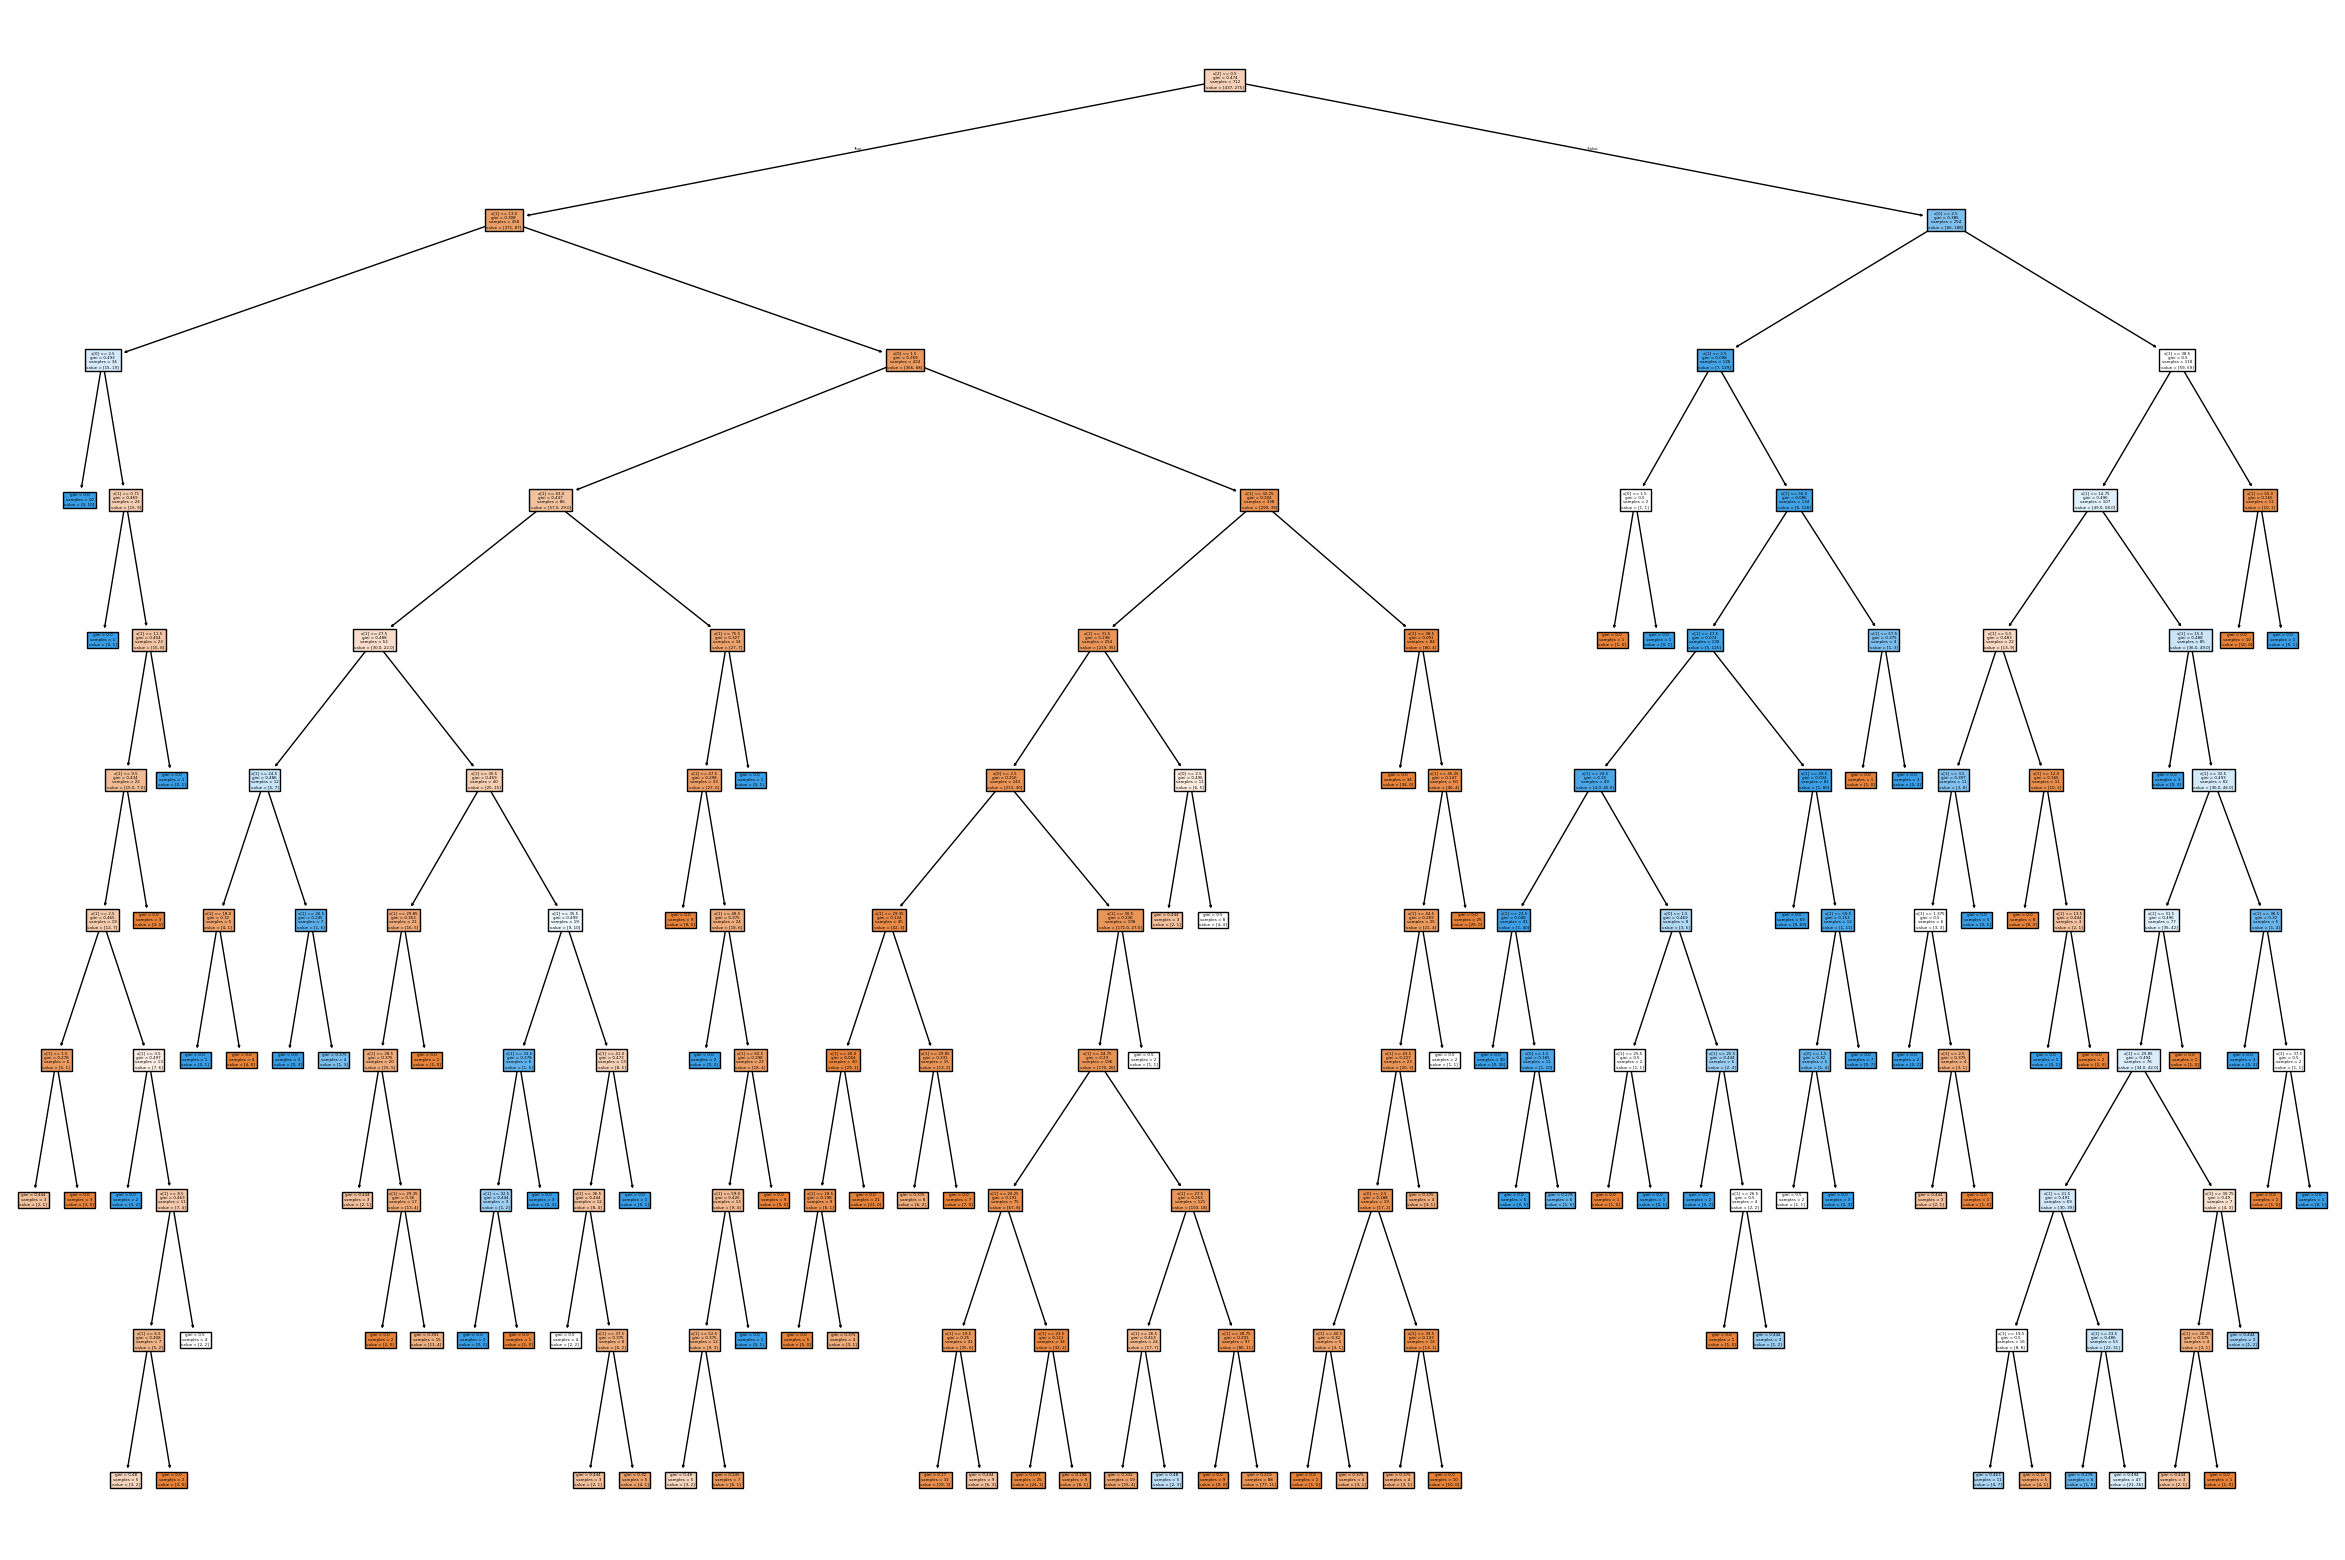

In [14]:
"""
案例:
    演示 CART 分类回归决策树的 分类功能
"""

# 导包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree

# 1.加载数据
data = pd.read_csv('../data/titanic_train.csv')
#data.info()

# 2. 数据预处理
# 2.1 提取特征和标签
x = data[['Pclass', 'Sex', 'Age']]
y = data['Survived']
# (x.head(),y.head())
# 2.2 发现Age列有缺失, 我们用该列的 平均值做填充
#x['Age'].fillna(x['Age'].mean(), inplace=True)  # 可以使用,但是会报警告
#x['Age'] = x['Age'].fillna(x['Age'].mean())      # 会报警告,因为是直接修改原数据的
x = x.copy()
x['Age'] = x['Age'].fillna(x['Age'].mean())

# 2.3 针对 Sex列, 进行one-hot处理
x = pd.get_dummies(x, columns=['Sex'])
# x.info()
# 2.4 数据集分割
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=25)

# 3.特征工程

# 4. 模型训练
# 参数: max_depth=10 表示: 决策树结构, 最多10层
estimator = DecisionTreeClassifier(max_depth=10)
estimator.fit(x_train, y_train)

# 5. 模型预测
y_pred = estimator.predict(x_test)
print(f"预测值为: {y_pred[:5]}")

# 6.模型评估
print(f"分类评估报告: {classification_report(y_test, y_pred)}")

# 7. 绘制 决策树
plt.figure(figsize=(30, 20))    # 设置图片大小, 30 *100(dpi) * 20 *100(dpi) = 3000 * 2000
# 参1: estimator: 模型; 参2: 填充颜色; 参3: 最多显示10层
plot_tree(estimator,filled=True,max_depth=10)
plt.savefig('../data/titanic_decision_tree.png')
plt.show()